In [1]:
# !pip install scikeras
# !pip install --upgrade "scikit-learn<1.6.0"

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

In [3]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [6]:
test_images.shape

(10000, 28, 28)

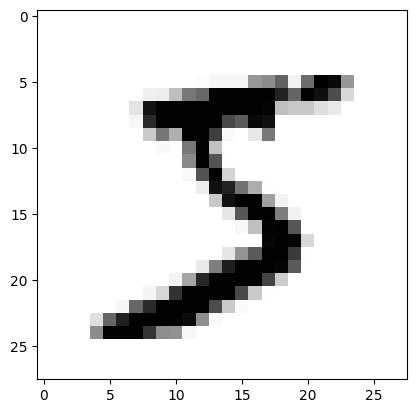

In [7]:
plt.imshow(train_images[0], cmap="Greys")

In [8]:
# model 

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(784, )))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# data preprocessing

train_images = train_images.reshape((60000, 784))
train_images = train_images.astype('float32') / 255.0

test_images = test_images.reshape((10000, 784))
test_images = test_images.astype('float32') / 255.0

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [10]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8708 - loss: 0.4426
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9705 - loss: 0.0962
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9827 - loss: 0.0557
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9880 - loss: 0.0369
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9920 - loss: 0.0250


In [11]:
pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [12]:
for idx, prediction in enumerate(pred[:5]):
    test_result = np.where(test_labels[idx] == 1)[0][0]
    predict_result = np.where(prediction == max(prediction))[0][0]
    
    print(f'test_labels: {test_result}, prediction: {predict_result}')

# pred[:5], test_labels[:5]

test_labels: 7, prediction: 7
test_labels: 2, prediction: 2
test_labels: 1, prediction: 1
test_labels: 0, prediction: 0
test_labels: 4, prediction: 4


In [13]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'테스트 정확도: {test_acc}, test loss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9777 - loss: 0.0779
테스트 정확도: 0.9805999994277954, test loss: 0.06554743647575378


In [14]:
def build_model():
    network = tf.keras.models.Sequential()

    network.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(784, )))
    network.add(tf.keras.layers.Dense(128, activation='relu'))
    network.add(tf.keras.layers.Dense(10, activation='softmax'))
    
    network.compile(
        optimizer='adam', 
        loss='categorical_crossentropy', 
        metrics=['accuracy'])
    
    return network

In [15]:
param_grid ={
    'epochs' : [1, 2, 3],
    'batch_size' : [32, 64]
}

model = KerasClassifier(build_fn = build_model, verbose=1)

In [16]:
gs = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    n_jobs=1
)

grid_result = gs.fit(train_images, train_labels)
print(grid_result.best_score_)
print(grid_result.best_params_)

C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8840 - loss: 0.3900
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8807 - loss: 0.3869
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8644 - loss: 0.4558
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9706 - loss: 0.0938
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9824 - loss: 0.0542
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Epoch 1/3


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8763 - loss: 0.4285
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9692 - loss: 0.0989
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9810 - loss: 0.0616
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Epoch 1/3


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9054 - loss: 0.3200
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9756 - loss: 0.0782
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9838 - loss: 0.0507
0.9703166666666667
{'batch_size': 32, 'epochs': 3}
